# Prosody transfer between Kokoro voices: pitch, energy, duration

The **target** voice gives the timbre. Any combination of prosody can come from the **donor** voice:

| what | how it is transferred | normalization |
|---|---|---|
| duration | donor's per-phoneme durations | optional: rescale to the target's total length (keep donor rhythm, target tempo) |
| pitch (F0) | donor's F0 contour | log-F0 z-score on voiced frames → target's mean (and range) |
| energy (N) | donor's energy contour | z-score (N is already log-like) → target's mean (and range) |

Whatever is *not* transferred comes from the target's own prediction. Pitch and energy are always predicted on the same alignment, so the curves stay frame-aligned.

In [1]:
from functions import * 
from functions import  _voice_pack, _encode,   predict_durations   , align_phonemes   # model, g2p, _encode, _voice_pack, predict_durations, align_phonemes, SR, FRAME_SAMPLES
import torch, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Audio

c:\Users\utente\anaconda3\envs\koko\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\utente\anaconda3\envs\koko\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(
c:\Users\utente\anaconda3\envs\koko\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


## Model helpers

In [2]:
@torch.no_grad()
def make_alignment(ps, dur):
    """Token-to-frame alignment matrix (1, n_tokens, n_frames) from durations."""
    dev = model.device
    n = _encode(ps)["n"]
    dur = torch.as_tensor(dur, device=dev).long().clamp(min=0).reshape(-1)
    assert dur.shape[0] == n, f"durations ({dur.shape[0]}) != tokens incl. BOS/EOS ({n})"
    idx = torch.repeat_interleave(torch.arange(n, device=dev), dur)
    aln = torch.zeros((n, idx.shape[0]), device=dev)
    aln[idx, torch.arange(idx.shape[0], device=dev)] = 1
    return aln.unsqueeze(0)


@torch.no_grad()
def predict_f0n(ps, pack, aln):
    """Predicted F0 (Hz) and energy N of voice `pack` on the given alignment, as numpy (2*n_frames,)."""
    enc = _encode(ps)
    s = pack[len(ps) - 1][:, 128:]
    d = model.predictor.text_encoder(enc["d_en"], s, enc["L"], enc["tm"])
    F0, N = model.predictor.F0Ntrain(d.transpose(-1, -2) @ aln, s)
    return F0.squeeze().cpu().numpy(), N.squeeze().cpu().numpy()


@torch.no_grad()
def decode(ps, pack, aln, f0, n):
    """Decoder with voice `pack`'s timbre and the GIVEN F0 / energy curves (numpy)."""
    enc = _encode(ps)
    ref_s = pack[len(ps) - 1]
    to_t = lambda x: torch.as_tensor(x, dtype=torch.float32, device=model.device).unsqueeze(0)
    return model.decoder(enc["t_en"] @ aln, to_t(f0), to_t(n), ref_s[:, :128]).squeeze().cpu().numpy()

## Normalization

In [3]:
VOICED_HZ = 50.0   # F0 frames below this count as unvoiced

def _z_transfer(x_donor, x_target, mask_d, mask_t, mode):
    """Move x_donor (on mask_d) into x_target's statistics (on mask_t)."""
    mu_d, sd_d = x_donor[mask_d].mean(), x_donor[mask_d].std()
    mu_t, sd_t = x_target[mask_t].mean(), x_target[mask_t].std()
    z = x_donor - mu_d
    if mode == "meanstd":
        z = z / (sd_d + 1e-8) * sd_t
    elif mode == "raw":
        return x_donor.copy()
    return z + mu_t


def normalize_f0(f0_d, f0_t, mode="meanstd", thr=VOICED_HZ):
    """Donor's F0 shape in the target's register (log domain, voiced frames).
    mode: "raw" (no normalization), "mean" (shift only), "meanstd" (shift + range).
    Unvoiced frames keep the donor's values -> voicing follows the donor."""
    vd, vt = f0_d > thr, f0_t > thr
    out = f0_d.copy()
    lf = _z_transfer(np.log(np.maximum(f0_d, 1e-3)), np.log(np.maximum(f0_t, 1e-3)), vd, vt, mode)
    out[vd] = np.exp(lf[vd])
    return out


def normalize_energy(n_d, n_t, mode="meanstd"):
    """Donor's energy shape at the target's level. Kokoro's N is already log-like,
    so a linear z-score is used. Stats on all frames."""
    all_d, all_t = np.ones_like(n_d, bool), np.ones_like(n_t, bool)
    return _z_transfer(n_d, n_t, all_d, all_t, mode)


def normalize_durations(dur_d, dur_t, mode="rate"):
    """mode "raw":  donor durations as they are (donor rhythm AND tempo).
            "rate": rescale so the total equals the target's (donor rhythm, target tempo).
    Rounding is done on the cumulative sum, so the total is exact and nothing drifts."""
    dur_d = np.asarray(dur_d, float)
    if mode == "raw":
        return dur_d.astype(int).tolist()
    scaled = dur_d * (sum(dur_t) / dur_d.sum())
    edges = np.round(np.concatenate([[0], np.cumsum(scaled)])).astype(int)
    return np.maximum(np.diff(edges), 1).tolist()

## Transfer function

In [4]:
def prosody_transfer(ps, target_voice, donor_voice,
                     pitch=True, energy=True, duration=False,
                     f0_mode="meanstd", energy_mode="meanstd", dur_mode="rate"):
    """Target timbre + any mix of the donor's pitch / energy / duration.
    Returns (audio, info dict with all curves for plotting)."""
    tpack, _ = _voice_pack(target_voice)
    dpack, _ = _voice_pack(donor_voice)

    dur_t = predict_durations(ps, tpack)
    dur_d = predict_durations(ps, dpack)
    dur = normalize_durations(dur_d, dur_t, dur_mode) if duration else dur_t
    aln = make_alignment(ps, dur)

    # both voices predicted on the SAME alignment -> frame-aligned curves
    f0_t, n_t = predict_f0n(ps, tpack, aln)
    f0_d, n_d = predict_f0n(ps, dpack, aln)

    f0 = normalize_f0(f0_d, f0_t, f0_mode)       if pitch  else f0_t
    n  = normalize_energy(n_d, n_t, energy_mode) if energy else n_t

    audio = decode(ps, tpack, aln, f0, n)
    info = dict(ps=ps, dur=dur, dur_t=dur_t, dur_d=dur_d,
                f0=f0, f0_t=f0_t, f0_d=f0_d, n=n, n_t=n_t, n_d=n_d,
                target=target_voice, donor=donor_voice,
                what=[k for k, v in [("pitch", pitch), ("energy", energy), ("duration", duration)] if v])
    return audio, info


def natural(ps, voice):
    """Voice with its own prosody (reference for listening)."""
    pack, _ = _voice_pack(voice)
    dur = predict_durations(ps, pack)
    aln = make_alignment(ps, dur)
    return decode(ps, pack, aln, *predict_f0n(ps, pack, aln))

## Plot

In [5]:
def _stats_line(name, f0, n, dur):
    v = f0[f0 > VOICED_HZ]
    return (f"{name:12s} F0 {np.exp(np.log(v).mean()):6.1f} Hz  ±{12*np.log2(np.e)*np.log(v).std():4.1f} st   "
            f"energy {n.mean():6.2f} ±{n.std():5.2f}   length {sum(dur)*FRAME_SAMPLES/SR:5.2f} s")


def plot_transfer(info, audio):
    nan = lambda x, m: np.where(m, x, np.nan)
    f0_t, f0_d, f0 = info["f0_t"], info["f0_d"], info["f0"]
    t = np.arange(len(f0)) * (FRAME_SAMPLES / 2) / SR          # F0/N frame = half a duration frame
    segs, _, _ = align_phonemes(info["ps"], info["dur"], n_samples=len(audio))

    fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=False)
    T, D, O = dict(label=f"target ({info['target']})", alpha=.7), dict(label=f"donor ({info['donor']})", alpha=.7), \
              dict(label="output", lw=2, color="k")

    ax = axes[0]                                                # raw F0
    for f, kw in [(f0_t, T), (f0_d, D), (f0, O)]:
        ax.plot(t, nan(f, f > VOICED_HZ), **kw)
    ax.set_ylabel("F0 (Hz)"); ax.set_title("Pitch (raw)"); ax.legend(loc="upper right")

    ax = axes[1]                                                # F0 shape
    for f, kw in [(f0_t, T), (f0_d, D), (f0, {**O, "ls": "--"})]:
        lf = np.log(np.maximum(f, 1e-3)); v = f > VOICED_HZ
        ax.plot(t, nan((lf - lf[v].mean()) / lf[v].std(), v), **kw)
    ax.set_ylabel("z(log F0)"); ax.set_title("Pitch shape (register removed)")

    ax = axes[2]                                                # energy
    for x, kw in [(info["n_t"], T), (info["n_d"], D), (info["n"], O)]:
        ax.plot(t, x, **kw)
    ax.set_ylabel("N"); ax.set_title("Energy")

    for ax in axes[:3]:                                         # phoneme grid on the time plots
        ax.set_xlim(0, t[-1])
        for lab, s, e, inf in segs:
            ax.axvline(s, color="gray", lw=.4, alpha=.4)
    for lab, s, e, inf in segs:
        if inf["kind"] == "phone":
            axes[0].text((s + e) / 2, axes[0].get_ylim()[1], lab, ha="center", va="bottom", fontsize=9)
    axes[2].set_xlabel("time (s)")

    ax = axes[3]                                                # durations per token, in ms
    labels = ["BOS"] + [c for c in info["ps"] if c in VOCAB] + ["EOS"]
    x = np.arange(len(labels)); w = .28; ms = 1000 * FRAME_SAMPLES / SR
    ax.bar(x - w, np.array(info["dur_t"]) * ms, w, label="target")
    ax.bar(x,     np.array(info["dur_d"]) * ms, w, label="donor")
    ax.bar(x + w, np.array(info["dur"])   * ms, w, label="output", color="k")
    ax.set_xticks(x); ax.set_xticklabels([LABEL_DISPLAY.get(l, l) for l in labels], fontsize=8)
    ax.set_ylabel("ms"); ax.set_title("Durations per token"); ax.legend(loc="upper right")

    fig.suptitle(f"{info['target']} with {info['donor']}'s " + (" + ".join(info["what"]) or "nothing"), fontsize=13)
    plt.tight_layout(); plt.show()

    print(_stats_line("target", f0_t, info["n_t"], info["dur_t"]))
    print(_stats_line("donor",  f0_d, info["n_d"], info["dur_d"]))
    print(_stats_line("output", f0,   info["n"],   info["dur"]))

## Settings

In [6]:
text = """Il gatto dorme sotto il ramo verde;Maria compra il pane fresco ogni mattina; Il treno parte alle otto di sera; Mio fratello studia la storia a Roma."""
target_voice = "im_nicola"    # timbre + register of the output
donor_voice  = "jf_alpha"      # where the prosody comes from

ps = text_to_ipa_chunks(text)[0]           # one sentence for simplicity
print(ps)

print("target (natural)"); display(Audio(natural(ps, target_voice), rate=SR))
print("donor (natural)");  display(Audio(natural(ps, donor_voice),  rate=SR))

il ɡˈatːo dˈɔrme sˈotːo il rˈamo vˈerde;mˌarˈiːa kˈompra il pˈane frˈesko ˌoɲɲɪ matːˈina; il trˈɛno pˈarte ˌalle ˈɔtːo dɪ sˈera; mˌio fratˈɛllo stˈudia la stˈɔria a rˈoma.
target (natural)


donor (natural)


## 1) Pitch + energy

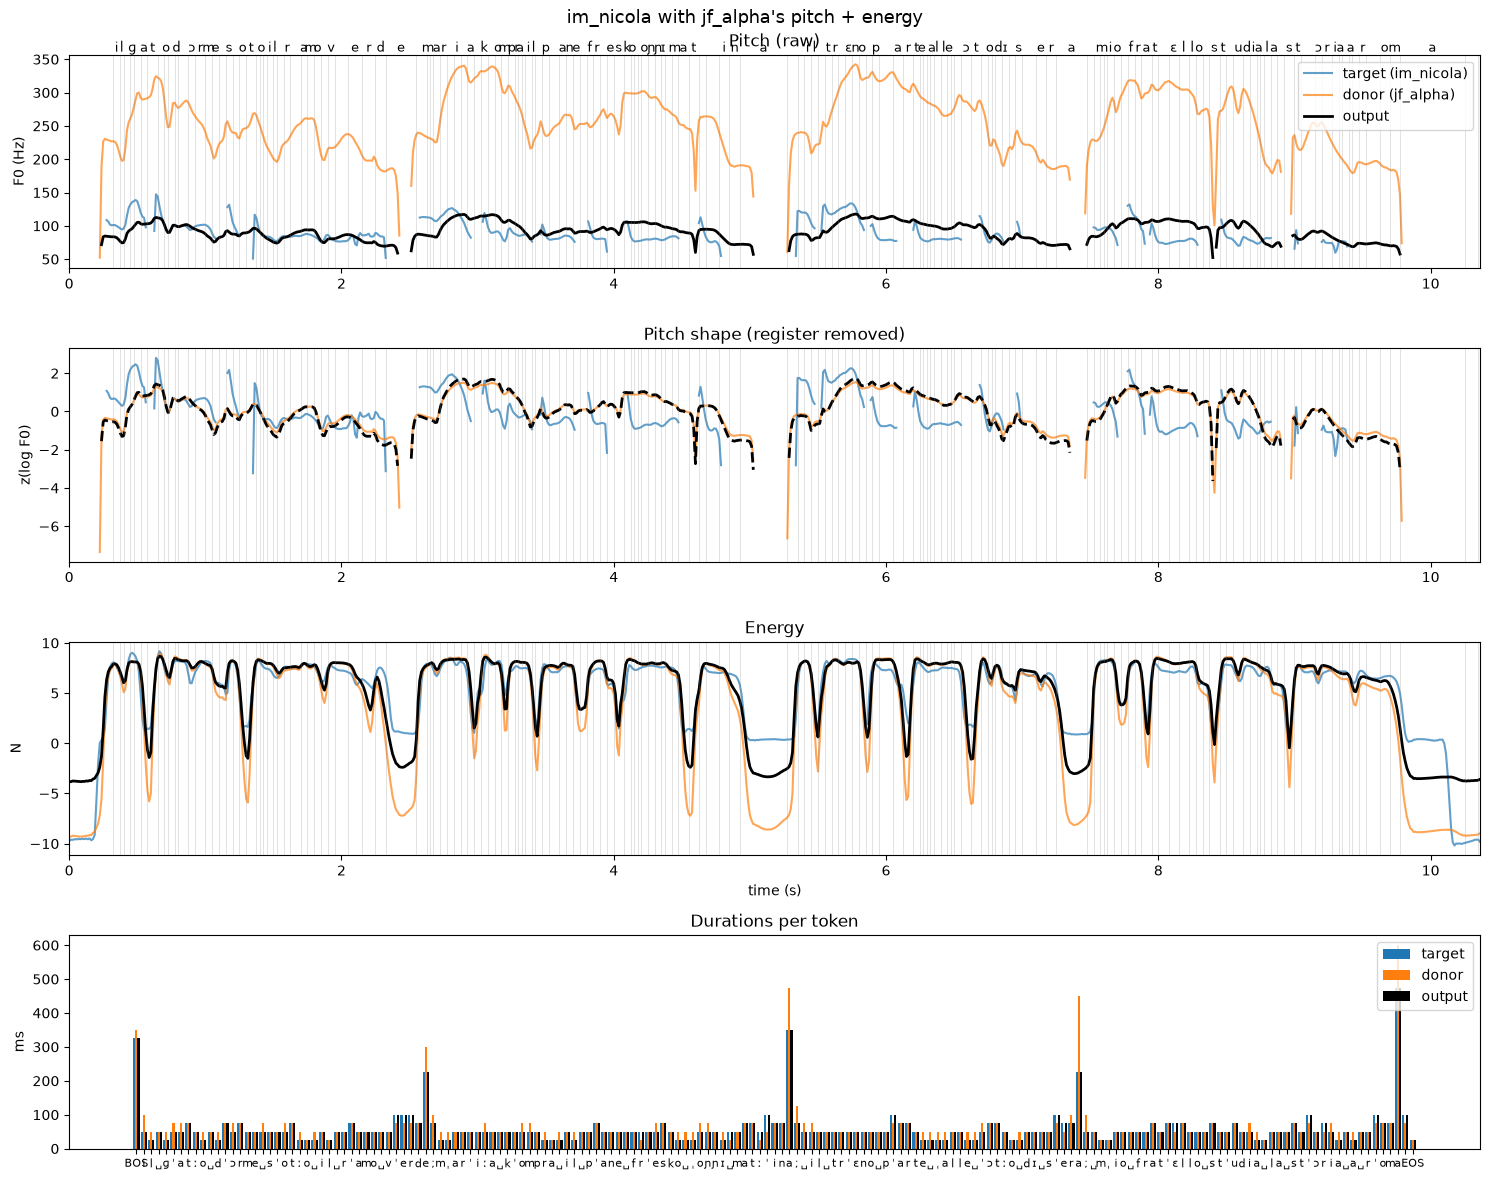

target       F0   89.9 Hz  ± 3.1 st   energy   5.11 ± 3.99   length 10.38 s
donor        F0  247.6 Hz  ± 3.7 st   energy   3.74 ± 5.82   length 11.78 s
output       F0   90.7 Hz  ± 2.6 st   energy   5.11 ± 3.99   length 10.38 s


In [7]:
audio_pe, info_pe = prosody_transfer(ps, target_voice, donor_voice,
                                     pitch=True, energy=True, duration=False)
display(Audio(audio_pe, rate=SR))
plot_transfer(info_pe, audio_pe)

## 2) Pitch + energy + duration

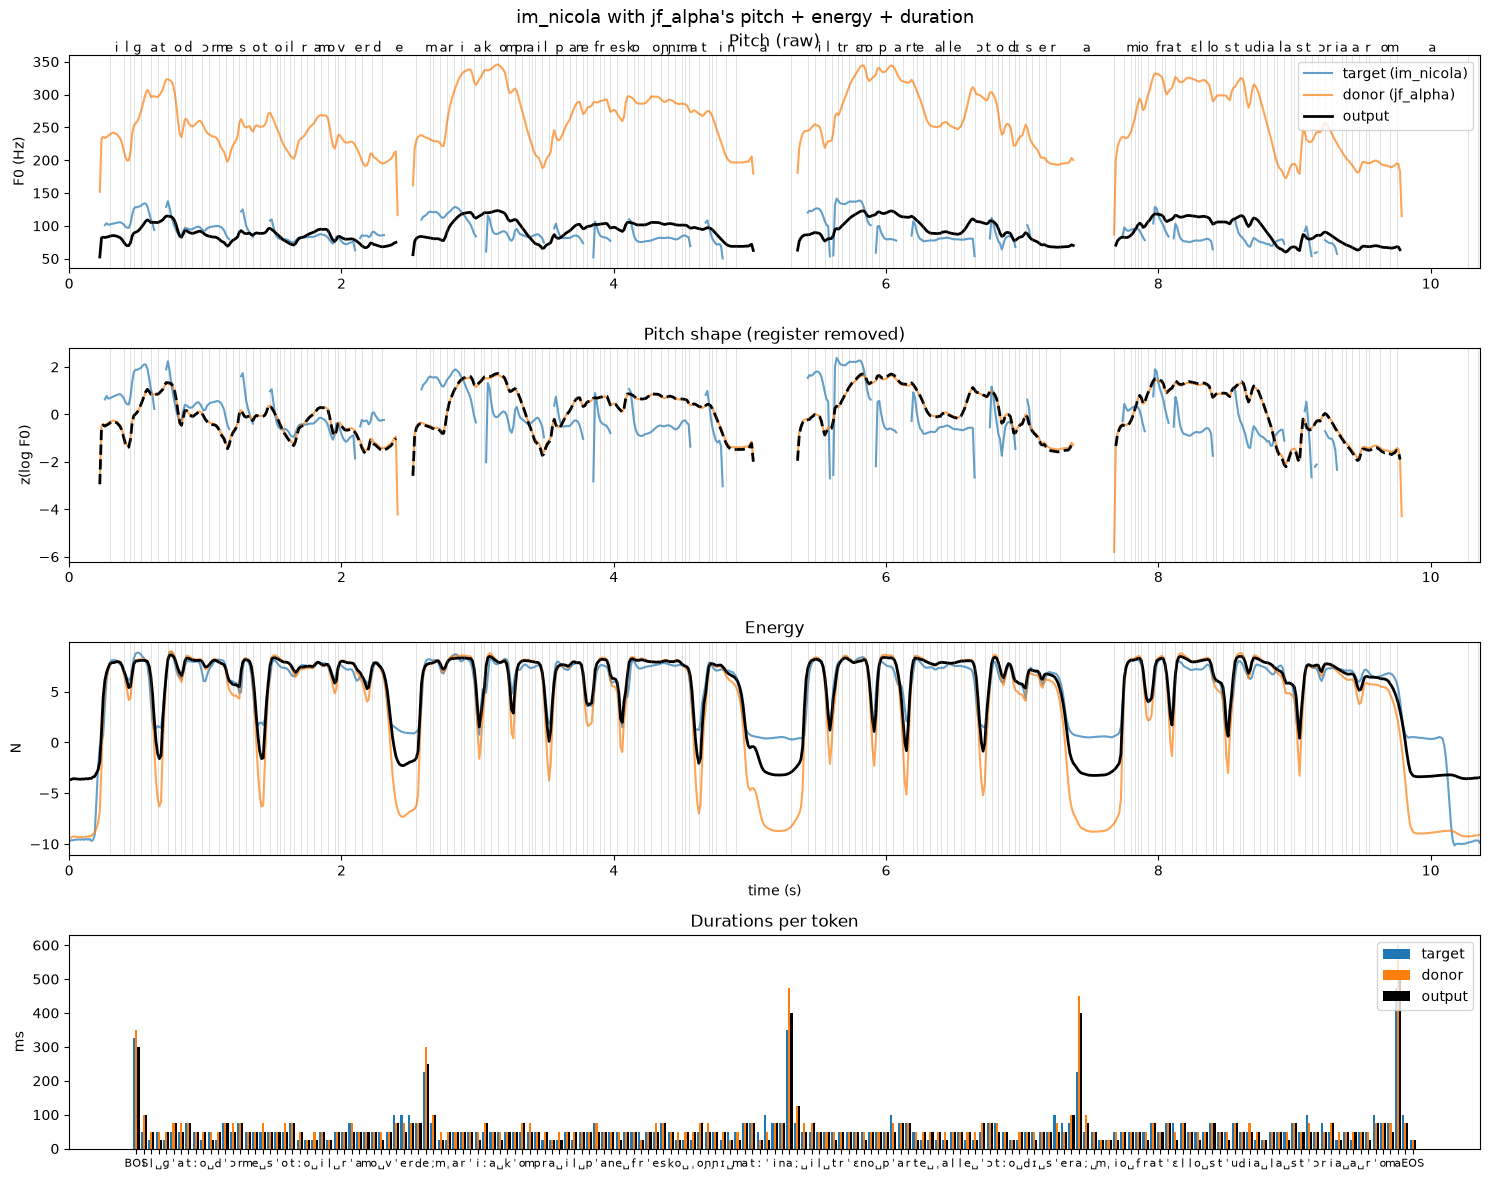

target       F0   89.6 Hz  ± 3.3 st   energy   5.02 ± 4.05   length 10.38 s
donor        F0  254.2 Hz  ± 3.2 st   energy   3.61 ± 6.07   length 11.78 s
output       F0   90.0 Hz  ± 3.2 st   energy   5.02 ± 4.05   length 10.38 s


In [10]:
audio_ped, info_ped = prosody_transfer(ps, target_voice, donor_voice,
                                       pitch=True, energy=True, duration=True,
                                       dur_mode="rate")   # "raw" = also take the donor's tempo
display(Audio(audio_ped, rate=SR))
plot_transfer(info_ped, audio_ped)

## Other combinations
Any mix works, e.g. `pitch=True, energy=False, duration=True`.
Modes: `f0_mode` / `energy_mode` = `"raw"`, `"mean"`, `"meanstd"`; `dur_mode` = `"raw"`, `"rate"`.